# Defensive Only FF4 Beta Portfolio

이 노트북은 여러 국면전환 실험을 제거하고, 최종적으로 가장 안정적인 결과를 보였던 `Defensive Only` 전략만 남긴 버전이다.

핵심 아이디어는 단순하다.

1. 유동성/시가총액/상장기간 기준으로 투자 가능한 종목군을 정한다.
2. 일별 FF4 롤링 회귀로 종목별 베타를 추정한다.
3. 추정이 불안정한 종목은 `t-stat` 기준으로 제거한다.
4. 남은 종목 중에서 방어적 성격이 강한 종목을 점수화해 상위 20%를 동일가중으로 보유한다.

이 버전에서는 EGARCH, 거래량 항, Markov Switching 같은 국면전환 모형을 메인 전략에 사용하지 않는다. 이전 실험에서는 고정 방어 포트폴리오가 국면전환 전략보다 더 높은 성과와 더 나은 위험조정성과를 보였기 때문이다.


### 0. 라이브러리 import 및 데이터 불러오기

In [465]:
import pandas as pd
import numpy as np

PRICE_FILE = "2000_2026_코스피코스닥_수정주가_일별_비영업일제외.csv"
TRADING_VALUE_FILE = "2000_2026_코스피코스닥_거래대금_일별_비영업일제외.csv"
MCAP_FILE = "2000_2026_코스피코스닥_시가총액_일별_비영업일제외.csv"
FACTOR_FILE = "2000_2026_KOSPI200, SMB, HML, MOM_수정종가_91CD_알별_비영업일제외.csv"

price = pd.read_csv(PRICE_FILE, index_col=0, parse_dates=True).sort_index()
trading_value = pd.read_csv(TRADING_VALUE_FILE, index_col=0, parse_dates=True).sort_index()
mcap = pd.read_csv(MCAP_FILE, index_col=0, parse_dates=True).sort_index()
factor = pd.read_csv(FACTOR_FILE, index_col=0, parse_dates=True).sort_index()

### 1. 초기 작업 및 설정

여기서는 일별 수익률, 팩터 수익률, 무위험수익률을 만들고 회귀에 사용할 공통 거래일을 정렬한다.

추가로 극단치가 회귀와 변동성 계산을 왜곡하지 않도록 수익률과 팩터 수익률에 윈저라이징을 적용한다. 현재 기본 설정은 양쪽 0.5% 꼬리를 절단하는 방식이다.


In [466]:
# 일별 단순 수익률, 로그 수익률 생성
ret = price.pct_change(fill_method=None).iloc[1:]
logret = np.log(price / price.shift(1)).iloc[1:]

def winsorize_df(df, lower=0.005, upper=0.995):
    lower_q = df.quantile(lower)
    upper_q = df.quantile(upper)
    return df.clip(lower=lower_q, upper=upper_q, axis=1)

# factor 설정 (일별 변화로)
rf_col = "CD(91)" if "CD(91)" in factor.columns else "91CD"
factor_ret = factor[["KOSPI200", "SMB", "HML", "MOM"]].pct_change(fill_method=None).iloc[1:]
rf = ((1 + factor[rf_col].iloc[1:] / 100) ** (1 / 252)) - 1  # 연금리 일금리변환

# raw data 따로 분리 (윈저라이징 전 원본 보관)
ret_raw = ret.copy()
logret_raw = logret.copy()
factor_ret_raw = factor_ret.copy()

# 극단치 완화
ret = winsorize_df(ret)
logret = winsorize_df(logret)
factor_ret = winsorize_df(factor_ret)

factor_ret["RF"] = rf
factor_ret["MKT"] = factor_ret["KOSPI200"] - factor_ret["RF"]
ff4 = factor_ret[["MKT", "SMB", "HML", "MOM"]]

# 회귀에 사용할 공통 거래일 정렬
common_index = ret.index.intersection(ff4.index)
ret = ret.loc[common_index]
logret = logret.loc[common_index]
rf = rf.loc[common_index]
ff4 = ff4.loc[common_index]
excess_ret = ret.sub(rf, axis=0)
ret_raw = ret_raw.loc[common_index]
logret_raw = logret_raw.loc[common_index]
factor_ret_raw = factor_ret_raw.loc[common_index]

### 2. 유니버스 및 베타 추정 설정

`BETA_WINDOW`는 FF4 베타를 추정할 롤링 창 길이이고, 현재 메인 사양은 `252거래일(약 1년)`이다. 이는 시변 베타를 비교적 민감하게 반영하면서도 추정오차를 과도하게 키우지 않기 위한 절충안이다.

`MIN_OBS`는 실제 회귀에 필요한 최소 유효 관측치 수다. 현재는 롤링 창의 75% 수준으로 설정했다.


In [467]:
# 베타 추정 설정
BETA_WINDOW = 252  # 메인 사양: 1년(약 252거래일)
MIN_OBS = int(BETA_WINDOW * 0.75)

# 60일 평균 거래대금
adv60 = trading_value.rolling(60).mean()

# 최근 60일 실제 거래일
trade_days_60 = trading_value.rolling(60).count()

# 월말 리밸런싱 날짜: 각 월의 실제 마지막 거래일 사용
rebalance_dates = pd.DatetimeIndex(price.index.to_series().groupby(price.index.to_period("M")).last())

# 베타 룩백이 가능한 시점부터만 분석
eligible_rebalance_dates = rebalance_dates[rebalance_dates.isin(excess_ret.index)]
analysis_start_date = eligible_rebalance_dates[eligible_rebalance_dates >= excess_ret.index[BETA_WINDOW - 1]][0]
rebalance_dates = eligible_rebalance_dates[eligible_rebalance_dates >= analysis_start_date]

In [468]:
# 월말 데이터
monthly_price = price.loc[rebalance_dates]
monthly_adv60 = adv60.loc[rebalance_dates]
monthly_trade_days_60 = trade_days_60.loc[rebalance_dates]
monthly_mcap = mcap.loc[rebalance_dates]

### 3. 기본 필터링

투자 가능 종목군은 다음 기준을 동시에 만족해야 한다.

- 가격 1,500원 이상
- 최근 60거래일 중 50거래일 이상 거래
- 거래대금 하위 20% 제외
- 시가총액 하위 10% 제외
- 상장 후 최소 `BETA_WINDOW` 거래일 이상 경과

즉 지나치게 작은 종목, 거래가 부실한 종목, 상장 이력이 짧은 종목은 제외한다.


In [469]:
# 1500원 미만 동전주 제거
price_filter = monthly_price >= 1500

# 최근 거래 60일 중 50일 미만 종목 제거
trade_days_filter = monthly_trade_days_60 >= 50

# 거래대금 하위 20% 제거
adv_rank_filter = monthly_adv60.rank(axis=1, pct=True) > 0.20

# 시가총액 하위 10% 제거
mcap_rank_filter = monthly_mcap.rank(axis=1, pct=True) > 0.10

# 상장 후 베타 룩백 창 이상 지난 종목만 사용
trading_day_number = pd.Series(np.arange(len(price.index)), index=price.index)
first_valid_date = price.apply(pd.Series.first_valid_index)
first_valid_day_number = first_valid_date.map(trading_day_number)
rebalance_day_number = trading_day_number.loc[rebalance_dates]
listing_age = rebalance_day_number.to_numpy()[:, None] - first_valid_day_number.to_numpy()[None, :] + 1
monthly_listing_days = pd.DataFrame(listing_age, index=rebalance_dates, columns=price.columns)
listing_filter = monthly_listing_days >= BETA_WINDOW

# 필터 합치기
basic_filter = (
    price_filter
    & trade_days_filter
    & adv_rank_filter
    & mcap_rank_filter
    & listing_filter
)
basic_filter.loc[basic_filter.index[0]].head()

삼성전자          True
SK하이닉스        True
현대차           True
LG에너지솔루션     False
한화에어로스페이스     True
Name: 2002-01-31 00:00:00, dtype: bool

### 4. FF4 롤링 베타 추정

각 월말마다 최근 `BETA_WINDOW` 거래일을 사용해 FF4 회귀를 수행한다. 종속변수는 개별 종목의 초과수익률이고, 설명변수는 `MKT`, `SMB`, `HML`, `MOM`이다.

`fit_ols_numpy`는 `statsmodels` 대신 선형대수로 직접 OLS를 계산하는 함수다. 속도를 높이기 위한 구현이며, 회귀계수와 표준오차, 사용 관측치 수를 반환한다.


In [470]:
def fit_ols_numpy(y, x, min_obs=MIN_OBS):
    valid = np.isfinite(y) & np.isfinite(x).all(axis=1)
    nobs = int(valid.sum())
    if nobs < min_obs:
        return None

    X = np.column_stack([np.ones(nobs), x[valid]])
    y_valid = y[valid]
    dof = nobs - X.shape[1]
    if dof <= 0:
        return None

    xtx = X.T @ X
    xty = X.T @ y_valid
    if (not np.isfinite(xtx).all()) or (not np.isfinite(xty).all()):
        return None

    try:
        xtx_inv = np.linalg.inv(xtx)
    except np.linalg.LinAlgError:
        return None

    params = xtx_inv @ xty
    resid = y_valid - X @ params
    sigma2 = (resid @ resid) / dof
    if not np.isfinite(sigma2):
        return None
    se = np.sqrt(np.diag(xtx_inv) * sigma2)
    return params, se, nobs

In [471]:
# 베타 담을 데이터프레임 생성
beta_mkt = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=float)
beta_smb = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=float)
beta_hml = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=float)
beta_mom = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=float)
beta_se = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=float)
beta_t = pd.DataFrame(index=rebalance_dates, columns=ret.columns, dtype=float)

In [472]:
# FF4 rolling beta + beta se, t-stat 구하기
for dt in rebalance_dates:
    if dt not in excess_ret.index or dt not in ff4.index:
        continue

    end_idx = excess_ret.index.get_loc(dt)
    start_idx = end_idx - (BETA_WINDOW - 1)

    if start_idx < 0:
        continue

    candidate_mask = basic_filter.loc[dt].fillna(False)
    candidate_cols = candidate_mask.index[candidate_mask]
    if len(candidate_cols) == 0:
        continue

    window_index = excess_ret.index[start_idx:end_idx+1]
    y_window = excess_ret.loc[window_index, candidate_cols]
    x_values = ff4.loc[window_index].to_numpy(dtype=float)

    for col in candidate_cols:
        result = fit_ols_numpy(y_window[col].to_numpy(dtype=float), x_values)
        if result is None:
            continue

        params, se, nobs = result
        beta_mkt.loc[dt, col] = params[1]
        beta_smb.loc[dt, col] = params[2]
        beta_hml.loc[dt, col] = params[3]
        beta_mom.loc[dt, col] = params[4]
        beta_se.loc[dt, col] = se[1]
        if se[1] > 0:
            beta_t.loc[dt, col] = params[1] / se[1]

### 5. 추정 안정성 필터

베타가 계산되더라도 추정 오차가 큰 종목은 신호로 쓰기 어렵다. 그래서 시장베타의 `t-stat = beta / se`를 이용해 월별 하위 20% 종목을 제거한다.

이 단계는 ‘좋은 종목’을 고르는 단계가 아니라, ‘베타를 믿기 어려운 종목’을 제거하는 단계다.


In [473]:
# |t-stat| 하위 20% 제거
beta_t_filter = beta_t.abs().rank(axis=1, pct=True) > 0.20
final_filter = basic_filter & beta_t_filter

In [474]:
beta_mkt_raw = beta_mkt.copy()
beta_smb_raw = beta_smb.copy()
beta_hml_raw = beta_hml.copy()
beta_mom_raw = beta_mom.copy()
beta_se_raw = beta_se.copy()
beta_t_raw = beta_t.copy()

beta_mkt = beta_mkt.where(final_filter)
beta_smb = beta_smb.where(final_filter)
beta_hml = beta_hml.where(final_filter)
beta_mom = beta_mom.where(final_filter)
beta_se = beta_se.where(final_filter)
beta_t = beta_t.where(final_filter)

### 6. 베타 추정 검증

아래 표들은 베타 계산이 정상적으로 되었는지, 필터가 지나치게 강하지 않은지, 최종 표본의 분포가 상식적인지를 확인하기 위한 진단 셀이다.

특히 `beta_count_before_t`, `final_count`, `median_beta_t_before_t`를 통해
- 월별 계산 종목 수가 충분한지
- `t-stat` 필터가 실제로 종목을 제거하는지
- 베타 추정의 신뢰도가 어느 정도인지
를 확인할 수 있다.


#### 3-1. 월별 종목 수와 월별 중앙 `t-stat` 점검

이 표는 월별로 베타가 얼마나 계산되었는지와, 계산된 베타의 신뢰도가 어느 정도인지 요약한다.

열 설명:

- `beta_count_before_t`: `t-stat` 필터를 적용하기 전에 회귀가 실제로 계산된 종목 수
- `final_count`: 최종 필터까지 통과한 종목 수
- `median_beta_t_before_t`: 그 달에 계산된 `MKT beta t-stat`의 중앙값

해석 팁:

- `beta_count_before_t`가 너무 작으면 유니버스가 지나치게 좁거나 회귀 조건이 너무 빡센 것일 수 있다.
- `final_count`가 `beta_count_before_t`보다 꽤 작으면 `t-stat` 필터가 실제로 종목을 제거하고 있다는 뜻이다.
- `median_beta_t_before_t`가 높을수록 시장베타가 안정적으로 추정된 종목이 많다는 뜻이다.
- `tail(12)`는 최근 12개월의 상태를 빠르게 점검할 때 유용하다.

In [476]:
# 월별 계산/필터 통과 종목 수 요약
print("BETA_WINDOW:", BETA_WINDOW)
print("MIN_OBS:", MIN_OBS)
print("analysis_start_date:", analysis_start_date)

diagnostics = pd.DataFrame({
    "beta_count_before_t": beta_mkt_raw.notna().sum(axis=1),
    "final_count": final_filter.sum(axis=1),
    "median_beta_t_before_t": beta_t_raw.median(axis=1),
})

display(diagnostics.describe())
display(diagnostics.tail(12))

analysis_start_date: 2002-01-31 00:00:00


,beta_count_before_t,final_count,median_beta_t_before_t
count,291.000000,291.000000,291.000000
mean,1175.786942,941.013746,8.300120
std,319.787617,255.833162,2.075399
min,564.000000,452.000000,4.894092
25%,968.000000,774.500000,6.545626
50%,1154.000000,924.000000,8.267660
75%,1436.500000,1149.500000,9.869414
max,1683.000000,1347.000000,12.479021


,beta_count_before_t,final_count,median_beta_t_before_t
Date,,,
2025-04-30,1635,1308,8.273155
2025-05-30,1634,1308,8.267660
2025-06-30,1635,1308,8.463843
2025-07-31,1640,1312,8.515820
2025-08-29,1643,1315,8.524759
2025-09-30,1655,1324,8.696082
2025-10-31,1638,1311,8.609408
2025-11-28,1630,1304,8.681917
2025-12-30,1658,1327,8.574744


#### 3-2. 최종 베타와 `t-stat` 분포 점검

이 셀은 최종 필터 적용 후 남은 전체 표본의 분포를 확인한다.

출력 설명:

- `beta_mkt.stack().describe()`: 모든 월, 모든 종목의 최종 시장베타 분포 요약
- `beta_t.stack().describe()`: 모든 월, 모든 종목의 최종 `MKT beta t-stat` 분포 요약
- 히스토그램: `beta_mkt`가 어느 구간에 많이 몰려 있는지 시각적으로 확인

해석 팁:

- `beta_mkt`의 평균이나 중앙값이 극단적으로 크거나 작지 않은지 본다.
- `beta_mkt`의 `min`, `max`가 지나치게 튀면 일부 종목 회귀가 불안정한 것일 수 있다.
- `beta_t`의 중앙값이 너무 낮으면 회귀 신뢰도가 약하다는 신호일 수 있다.
- 히스토그램이 한쪽으로 너무 길게 늘어지면 이상치 점검이 필요할 수 있다.

count    273835.000000
mean          1.076576
std           0.303901
min          -1.051194
25%           0.864432
50%           1.075053
75%           1.281075
max           2.910012
dtype: float64

count    273835.000000
mean          9.474021
std           3.602470
min          -8.802931
25%           6.798096
50%           8.845916
75%          11.482854
max          43.006243
dtype: float64

<Axes: >

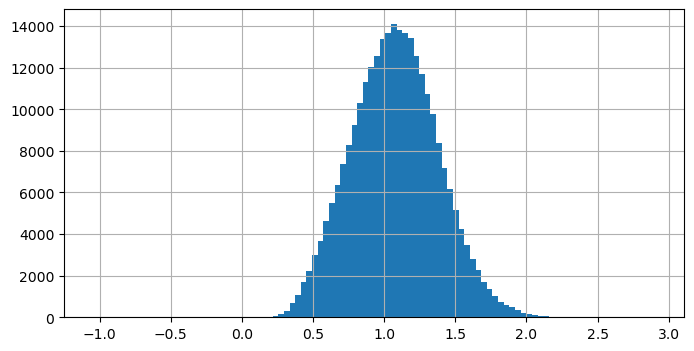

In [477]:
# 전체 분포 점검
display(beta_mkt.stack().describe())
display(beta_t.stack().describe())

beta_mkt.stack().hist(bins=100, figsize=(8, 4))

#### 3-3. 최근 월 기준 상위/하위 종목 점검

이 셀은 가장 최근 리밸런싱 날짜를 기준으로 종목별 값을 직접 확인한다.

출력 순서:

- 최근 월 `beta_mkt` 하위 10개
- 최근 월 `beta_mkt` 상위 10개
- 최근 월 `beta_t` 하위 10개
- 최근 월 `beta_t` 상위 10개

해석 팁:

- `beta_mkt` 상위 종목은 시장 민감도가 높은 종목일 가능성이 크다.
- `beta_mkt` 하위 종목은 방어주, 저베타주, 또는 특이한 가격 흐름을 가진 종목일 수 있다.
- `beta_t` 하위 종목은 베타 추정이 상대적으로 덜 안정적인 종목이다.
- 종목명이 전혀 납득되지 않게 반복해서 튀면 데이터 또는 회귀 설정을 다시 의심해볼 수 있다.

In [478]:
# 최근 월 기준 상하위 종목 확인
last_dt = beta_mkt.dropna(how="all").index[-1]
print("last rebalance date:", last_dt)

display(beta_mkt.loc[last_dt].dropna().sort_values().head(10))
display(beta_mkt.loc[last_dt].dropna().sort_values().tail(10))
display(beta_t.loc[last_dt].dropna().sort_values().head(10))
display(beta_t.loc[last_dt].dropna().sort_values().tail(10))

last rebalance date: 2026-03-13 00:00:00


정상제이엘에스    0.224820
한국기업평가     0.267801
메가스터디      0.314599
진양홀딩스      0.331865
아이마켓코리아    0.335618
창해에탄올      0.336783
이크레더블      0.338974
효성ITX      0.347892
KPX케미칼     0.355654
스카이라이프     0.375825
Name: 2026-03-13 00:00:00, dtype: float64

에이팩트        1.743292
오킨스전자       1.755014
와이씨         1.756326
덕산하이메탈      1.773812
삼화전기        1.807853
미래반도체       1.836659
코세스         1.846595
퀄리타스반도체     1.846634
에이디테크놀로지    1.860002
레이저쎌        1.930913
Name: 2026-03-13 00:00:00, dtype: float64

파라택시스이더리움    6.957119
동성화인텍        6.958064
노을           6.962239
율촌화학         6.962393
대성산업         6.970378
엔비티          6.970664
엔켐           6.976000
에코앤드림        6.991128
디어유          7.017984
리파인          7.025895
Name: 2026-03-13 00:00:00, dtype: float64

엘오티베큠       20.208282
인선이엔티       20.246909
SFA반도체      20.280785
SK하이닉스      20.317812
디와이         20.775702
동화약품        21.057662
아비코전자       21.268948
텔레칩스        21.689202
티이엠씨씨엔에스    22.805571
삼성전자        30.543037
Name: 2026-03-13 00:00:00, dtype: float64

#### 3-4. 필터 단계별 종목 수 비교

이 표는 각 필터 단계에서 종목 수가 어떻게 줄어드는지 보여준다.

열 설명:

- `basic_count`: 가격, 거래일수, 거래대금, 시가총액, 상장기간 조건까지 통과한 종목 수
- `beta_count_before_t`: 위 종목들 중 실제로 FF4 회귀가 계산된 종목 수
- `beta_t_count_before_t`: `t-stat`이 계산된 종목 수
- `final_count`: `t-stat` 필터까지 통과한 최종 종목 수
- `dropped_by_t_filter`: `t-stat` 필터 때문에 최종적으로 제외된 종목 수

해석 팁:

- `basic_count`와 `beta_count_before_t` 차이가 크면 회귀 창에서 결측이 많은 종목이 있다는 뜻일 수 있다.
- `beta_count_before_t`와 `final_count` 차이가 크면 `t-stat` 필터가 강하게 작동하고 있다는 뜻이다.
- `dropped_by_t_filter`가 계속 0이면 `t-stat` 필터가 사실상 의미가 없거나, 이미 매우 안정적인 종목들만 남아 있다는 뜻일 수 있다.
- 마지막 출력인 `beta_t_raw.abs().rank(axis=1, pct=True)`는 각 월에서 종목별 `|t-stat|` 백분위 순위를 보여준다.

In [479]:
# 필터 단계별 종목 수 확인
filter_counts = pd.DataFrame({
    "basic_count": basic_filter.sum(axis=1),
    "beta_count_before_t": beta_mkt_raw.notna().sum(axis=1),
    "beta_t_count_before_t": beta_t_raw.notna().sum(axis=1),
    "final_count": final_filter.sum(axis=1),
})
filter_counts["dropped_by_t_filter"] = filter_counts["beta_count_before_t"] - filter_counts["final_count"]

display(filter_counts.describe())
display(filter_counts.tail(12))
display(beta_t_raw.abs().rank(axis=1, pct=True).tail(3))

,basic_count,beta_count_before_t,beta_t_count_before_t,final_count,dropped_by_t_filter
count,291.000000,291.000000,291.000000,291.000000,291.000000
mean,1176.213058,1175.786942,1175.786942,941.013746,234.773196
std,319.825797,319.787617,319.787617,255.833162,63.955292
min,564.000000,564.000000,564.000000,452.000000,112.000000
25%,969.000000,968.000000,968.000000,774.500000,193.500000
50%,1154.000000,1154.000000,1154.000000,924.000000,230.000000
75%,1436.500000,1436.500000,1436.500000,1149.500000,287.000000
max,1683.000000,1683.000000,1683.000000,1347.000000,336.000000


,basic_count,beta_count_before_t,beta_t_count_before_t,final_count,dropped_by_t_filter
Date,,,,,
2025-04-30,1636,1635,1635,1308,327
2025-05-30,1635,1634,1634,1308,326
2025-06-30,1636,1635,1635,1308,327
2025-07-31,1640,1640,1640,1312,328
2025-08-29,1643,1643,1643,1315,328
2025-09-30,1655,1655,1655,1324,331
2025-10-31,1638,1638,1638,1311,327
2025-11-28,1630,1630,1630,1304,326
2025-12-30,1658,1658,1658,1327,331


,삼성전자,SK하이닉스,현대차,LG에너지솔루션,한화에어로스페이스,삼성바이오로직스,SK스퀘어,두산에너빌리티,HD현대중공업,기아,...,연합과기,차이나그레이트,중국원양자원,중국식품포장,에스앤씨엔진그룹,차이나하오란,웨이포트,성융광전투자유한공사,완리,골든센츄리
Date,,,,,,,,,,,,,,,,,,,,,
2026-01-30,1.0,0.999406,0.774807,0.052288,0.150921,0.017825,0.989305,0.707665,0.204397,0.834225,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-02-27,1.0,0.998797,0.654633,0.070397,0.121540,0.007220,0.984958,0.663057,0.161252,0.788809,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2026-03-13,1.0,0.996381,0.771411,0.189385,0.022316,0.042823,0.956574,0.597708,0.109771,0.870326,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 7. Shrinkage Beta

방어 포트폴리오를 만들기 전에 추정된 베타를 장기 평균 쪽으로 수축한다.

- 시장베타는 장기 평균을 1로 보고 1 쪽으로 shrink
- 스타일 베타는 장기 평균을 0으로 보고 0 쪽으로 shrink

이 과정은 추정 오차에 과민하게 반응하지 않도록 하기 위한 완화 장치다.


#### 시장 베타

$\tilde{\beta}_{MKT} = \lambda \hat{\beta}_{MKT} + (1-\lambda)\times 1$

시장 베타는 장기 평균이 1이라서
1쪽으로 shrink합니다.


#### 스타일 베타
$\tilde{\beta}_{k} = \lambda \hat{\beta}_{k} + (1-\lambda)\times0$

스타일 베타는 장기 평균이 0이라서
0쪽으로 shrink합니다.

In [480]:
# shrink beta 생성
shr_beta_mkt = 0.6 * beta_mkt + 0.4 * 1.0
shr_beta_smb = 0.6 * beta_smb
shr_beta_hml = 0.6 * beta_hml
shr_beta_mom = 0.6 * beta_mom

### 8. Defensive Only 포트폴리오 점수

방어 포트폴리오는 다음 특성을 선호한다.

- `shr_beta_mkt`가 낮을수록 좋음: 시장 급락 민감도가 낮은 종목 선호
- `shr_beta_smb`가 낮을수록 좋음: 작은 종목 편향이 과하지 않은 종목 선호
- `shr_beta_hml`가 높을수록 좋음: 상대적으로 가치 성격이 강한 종목 선호
- `beta_se`가 낮을수록 좋음: 베타 추정이 상대적으로 안정적인 종목 선호

이 네 점수를 백분위 순위로 바꾼 뒤 평균하여 `def_rank`를 만든다.


방어 포트폴리오

- shr_beta_mkt 낮을수록 좋음

- shr_beta_smb 낮을수록 좋음

- shr_beta_hml 높을수록 좋음

베타 추정 신뢰도는 이미 `t-stat` 필터에서 반영했지만,
종목 품질 통제를 위해 `beta_se`를 낮은 가중치로만 반영한다.

In [490]:
def_rank = (
    0.3 * (-shr_beta_mkt).rank(axis=1, pct=True)
    + 0.3 * (-shr_beta_smb).rank(axis=1, pct=True)
    + 0.3 * shr_beta_hml.rank(axis=1, pct=True)
    + 0.1 * (-beta_se).rank(axis=1, pct=True)
)

### 9. 최종 선택 및 저장

`def_rank`에 최종 필터를 반영한 뒤, 월별 상위 20% 종목을 `def_selected`로 선택한다. 아래 셀은 점수와 선택 결과를 CSV로 저장한다.

- `def_rank.csv`: 월별 방어 점수
- `def_selected.csv`: 월별 선택 여부(1/0)

필요하면 이 파일을 별도 분석이나 보고서 작성에 바로 사용할 수 있다.


In [ ]:
# 방어 점수에 최종 필터 반영
def_rank = def_rank.where(final_filter)

def_selected = def_rank.rank(axis=1, pct=True) >= 0.80


In [ ]:
# Defensive Only 모델 출력 CSV 저장
def_rank.to_csv("def_rank.csv", encoding="utf-8-sig")
def_selected.astype(int).to_csv("def_selected.csv", encoding="utf-8-sig")

print("saved:")
print("- def_rank.csv")
print("- def_selected.csv")


### 10. Defensive Only 백테스트

이제 방어 포트폴리오만 월별 리밸런싱으로 보유한다. 각 리밸런싱 날짜에서 선택된 종목을 동일가중으로 편입하고, 다음 리밸런싱 날짜 직전까지 보유한다.

마지막 부분월은 불완전한 보유구간이므로 제외한다.


In [ ]:
# 다음 리밸런싱 날짜까지 보유하되, 마지막 부분월은 제외
backtest_rebalance_dates = rebalance_dates[:-1]
next_rebalance_dates = rebalance_dates[1:]


In [ ]:
# 수익률 저장할 시리즈 생성
def_portfolio_ret = pd.Series(index=backtest_rebalance_dates, dtype=float)
def_portfolio_daily_ret = pd.Series(index=ret.index, dtype=float)


In [ ]:
# Defensive Only 월 리밸런싱
for i, dt in enumerate(backtest_rebalance_dates):
    end_dt = next_rebalance_dates[i]
    w = def_selected.loc[dt].astype(float)
    w = w[w > 0]

    if len(w) == 0:
        continue

    w = w / w.sum()
    holding_period = ret.loc[(ret.index > dt) & (ret.index <= end_dt), w.index]
    daily_port_ret = holding_period.mul(w, axis=1).sum(axis=1)

    def_portfolio_daily_ret.loc[daily_port_ret.index] = daily_port_ret
    def_portfolio_ret.loc[dt] = (1 + daily_port_ret).prod() - 1

def_portfolio_ret = def_portfolio_ret.dropna()
def_portfolio_daily_ret = def_portfolio_daily_ret.dropna()


In [ ]:
def_portfolio_ret.head()


### 11. 5분위 분석

`def_rank`를 기준으로 매월 종목을 5분위로 나눠서, 점수가 낮은 그룹(Q1)부터 높은 그룹(Q5)까지 각각 동일가중 포트폴리오를 만든다.

이 분석의 목적은 단순히 최상위 20% 전략만 보는 것이 아니라, 점수 체계가 전반적으로 단조로운 성과 패턴을 보이는지 확인하는 것이다.

- `Q1`: 가장 방어 점수가 낮은 20%
- `Q5`: 가장 방어 점수가 높은 20%
- `Benchmark`: KOSPI200 월간 수익률

이상적인 경우에는 Q1에서 Q5로 갈수록 성과가 개선되거나, 최소한 Q5가 Q1보다 뚜렷하게 좋아야 한다.


In [ ]:
def build_equal_weight_portfolio(selection_mask, rebalance_dates_used, ret):
    port_ret = pd.Series(index=rebalance_dates_used, dtype=float)
    port_daily_ret = pd.Series(index=ret.index, dtype=float)
    next_dates = list(rebalance_dates_used[1:]) + [rebalance_dates[-1]]

    for i, dt in enumerate(rebalance_dates_used):
        end_dt = next_dates[i]
        w = selection_mask.loc[dt].astype(float)
        w = w[w > 0]
        if len(w) == 0:
            continue

        w = w / w.sum()
        holding_period = ret.loc[(ret.index > dt) & (ret.index <= end_dt), w.index]
        daily_port_ret = holding_period.mul(w, axis=1).sum(axis=1)
        port_daily_ret.loc[daily_port_ret.index] = daily_port_ret
        port_ret.loc[dt] = (1 + daily_port_ret).prod() - 1

    return port_ret.dropna(), port_daily_ret.dropna()

quintile_masks = {}
for q in range(5):
    lower = q * 0.2
    upper = (q + 1) * 0.2
    rank_pct = def_rank.rank(axis=1, pct=True, method='first')
    if q == 0:
        quintile_masks[f'Q{q+1}'] = rank_pct <= upper
    else:
        quintile_masks[f'Q{q+1}'] = (rank_pct > lower) & (rank_pct <= upper)

quintile_returns = {}
for name, mask in quintile_masks.items():
    q_ret, _ = build_equal_weight_portfolio(mask.loc[backtest_rebalance_dates], backtest_rebalance_dates, ret)
    quintile_returns[name] = q_ret

benchmark_monthly = factor["KOSPI200"].loc[rebalance_dates].pct_change().loc[backtest_rebalance_dates].dropna()
quintile_result = pd.concat([pd.DataFrame(quintile_returns), benchmark_monthly.rename('Benchmark')], axis=1).dropna()


In [ ]:
import matplotlib.pyplot as plt

def performance_stats(r):
    r = r.dropna()
    if len(r) == 0:
        return pd.Series(dtype=float)

    wealth = (1 + r).cumprod()
    drawdown = wealth / wealth.cummax() - 1
    n_months = len(r)
    total_return = wealth.iloc[-1] - 1
    cagr = wealth.iloc[-1] ** (12 / n_months) - 1
    ann_vol = r.std() * np.sqrt(12)
    sharpe = np.nan if ann_vol == 0 else (r.mean() * 12) / ann_vol
    hit_rate = (r > 0).mean()

    return pd.Series({
        'CAGR': cagr,
        'Annualized Vol': ann_vol,
        'Sharpe': sharpe,
        'Max Drawdown': drawdown.min(),
        'Hit Rate': hit_rate,
        'Total Return': total_return,
    })

quintile_perf = pd.concat(
    {col: performance_stats(quintile_result[col]) for col in quintile_result.columns},
    axis=1,
)

display(quintile_perf)

bar_order = ['Q1', 'Q2', 'Q3', 'Q4', 'Q5', 'Benchmark']
bar_colors = ['#c44e52', '#dd8452', '#55a868', '#4c72b0', '#2f4b7c', '#8c8c8c']
bar_values = quintile_perf.loc['CAGR', bar_order]

plt.figure(figsize=(10, 5))
plt.bar(bar_order, bar_values, color=bar_colors, edgecolor='black', linewidth=0.6)
plt.axhline(0, color='black', linewidth=0.8)
plt.title('CAGR by Defensive Rank Quintile vs Benchmark')
plt.ylabel('CAGR')
plt.tight_layout()
plt.show()

cum_quintile = (1 + quintile_result[bar_order]).cumprod()
line_colors = {
    'Q1': '#c44e52',
    'Q2': '#dd8452',
    'Q3': '#55a868',
    'Q4': '#4c72b0',
    'Q5': '#2f4b7c',
    'Benchmark': '#8c8c8c',
}

plt.figure(figsize=(11, 6))
for col in bar_order:
    plt.plot(cum_quintile.index, cum_quintile[col], label=col, color=line_colors[col], linewidth=2.0)
plt.title('Cumulative Return by Defensive Rank Quintile vs Benchmark')
plt.ylabel('Cumulative Return Index')
plt.legend(ncol=3, frameon=False)
plt.tight_layout()
plt.show()


### 12. Q5-Q1 롱숏 분석

정렬 전략의 순수한 분리 능력을 보기 위해 `Q5 - Q1` 롱숏 포트폴리오를 계산한다.

- `Q5`: 가장 방어 점수가 높은 20% 롱
- `Q1`: 가장 방어 점수가 낮은 20% 숏

이 롱숏 포트폴리오는 시장 전체 방향보다 `def_rank`가 종목을 얼마나 잘 구분하는지 보여주는 데 더 직접적이다.

여기서는 누적수익률, 성과지표, 그리고 FF4 알파 유의성까지 함께 본다.

In [ ]:
long_short_ret = (quintile_result['Q5'] - quintile_result['Q1']).dropna()
long_short_cum = (1 + long_short_ret).cumprod()

display(performance_stats(long_short_ret).rename('Q5-Q1 Long-Short'))

plt.figure(figsize=(11, 5))
plt.plot(long_short_cum.index, long_short_cum, color='#1b3a57', linewidth=2.2)
plt.axhline(1.0, color='black', linewidth=0.8)
plt.title('Cumulative Return of Q5-Q1 Long-Short Portfolio')
plt.ylabel('Cumulative Return Index')
plt.tight_layout()
plt.show()


In [ ]:
rf_monthly_ls = pd.Series(index=backtest_rebalance_dates, dtype=float)
ff4_monthly_ls = pd.DataFrame(index=backtest_rebalance_dates, columns=['MKT', 'SMB', 'HML', 'MOM'], dtype=float)

for i, dt in enumerate(backtest_rebalance_dates):
    end_dt = next_rebalance_dates[i]
    period_mask = (ff4.index > dt) & (ff4.index <= end_dt)
    ff4_window = ff4.loc[period_mask]
    rf_window = rf.loc[(rf.index > dt) & (rf.index <= end_dt)]

    if len(ff4_window) > 0:
        ff4_monthly_ls.loc[dt] = (1 + ff4_window).prod() - 1
    if len(rf_window) > 0:
        rf_monthly_ls.loc[dt] = (1 + rf_window).prod() - 1

ls_alpha_test = pd.concat([
    long_short_ret.rename('portfolio'),
    rf_monthly_ls.rename('RF'),
    ff4_monthly_ls,
], axis=1).dropna()

y_ls = (ls_alpha_test['portfolio'] - ls_alpha_test['RF']).to_numpy(dtype=float)
X_ls = ls_alpha_test[['MKT', 'SMB', 'HML', 'MOM']].to_numpy(dtype=float)
X_ls = np.column_stack([np.ones(len(X_ls)), X_ls])

xtx_inv_ls = np.linalg.inv(X_ls.T @ X_ls)
params_ls = xtx_inv_ls @ (X_ls.T @ y_ls)
resid_ls = y_ls - X_ls @ params_ls
dof_ls = len(y_ls) - X_ls.shape[1]
sigma2_ls = (resid_ls @ resid_ls) / dof_ls
se_ls = np.sqrt(np.diag(xtx_inv_ls) * sigma2_ls)
tstats_ls = params_ls / se_ls
pvals_ls = 2 * (1 - stats.t.cdf(np.abs(tstats_ls), df=dof_ls))

ls_ff4_alpha_summary = pd.Series({
    'alpha_monthly': params_ls[0],
    'alpha_annualized': (1 + params_ls[0]) ** 12 - 1,
    'alpha_tstat': tstats_ls[0],
    'alpha_pvalue': pvals_ls[0],
    'significant_at_5pct': pvals_ls[0] < 0.05,
    'n_months': len(ls_alpha_test),
})

display(ls_ff4_alpha_summary)


### 13. 벤치마크 비교

벤치마크는 `KOSPI200` 월간 수익률이다. 동일 기간에서 `Defensive Only`와 벤치마크를 맞춰 비교한다.


In [ ]:
def_result = pd.concat(
    [
        def_portfolio_ret.rename("portfolio"),
        benchmark_monthly.rename("benchmark"),
    ],
    axis=1,
).dropna()


In [ ]:
def_result.head()


### 14. 성과지표

아래 표는 `Defensive Only`와 벤치마크의 핵심 성과지표를 비교한다.

- `CAGR`: 연환산 복리수익률
- `Annualized Vol`: 연환산 변동성
- `Sharpe`: 단순 샤프 비율
- `Max Drawdown`: 최대 낙폭
- `Hit Rate`: 월간 수익률이 플러스인 비율
- `Total Return`: 전체 기간 누적수익률


In [ ]:
def performance_stats(r):
    r = r.dropna()
    if len(r) == 0:
        return pd.Series(dtype=float)

    wealth = (1 + r).cumprod()
    drawdown = wealth / wealth.cummax() - 1
    n_months = len(r)
    total_return = wealth.iloc[-1] - 1
    cagr = wealth.iloc[-1] ** (12 / n_months) - 1
    ann_vol = r.std() * np.sqrt(12)
    sharpe = np.nan if ann_vol == 0 else (r.mean() * 12) / ann_vol
    hit_rate = (r > 0).mean()

    return pd.Series({
        "CAGR": cagr,
        "Annualized Vol": ann_vol,
        "Sharpe": sharpe,
        "Max Drawdown": drawdown.min(),
        "Hit Rate": hit_rate,
        "Total Return": total_return,
    })

perf_table = pd.concat(
    {
        "Defensive Only": performance_stats(def_result["portfolio"]),
        "Benchmark": performance_stats(def_result["benchmark"]),
    },
    axis=1,
)

display(perf_table)
display((1 + def_result).cumprod().tail())


### 15. FF4 알파 유의성 검정

`Defensive Only` 전략의 초과수익률이 FF4 요인으로 설명되고도 남는지 확인하기 위해 월별 FF4 회귀를 수행한다.

여기서는 다음 값을 본다.

- `alpha_monthly`: 월간 FF4 알파
- `alpha_annualized`: 연환산 알파
- `alpha_tstat`: 알파 t-통계량
- `alpha_pvalue`: 알파 p-value
- `significant_at_5pct`: 5% 유의수준에서 알파가 유의한지 여부

보통 `alpha_pvalue < 0.05`이면 알파가 통계적으로 유의하다고 해석한다.


In [ ]:
from scipy import stats

rf_monthly = pd.Series(index=backtest_rebalance_dates, dtype=float)
ff4_monthly = pd.DataFrame(index=backtest_rebalance_dates, columns=['MKT', 'SMB', 'HML', 'MOM'], dtype=float)

for i, dt in enumerate(backtest_rebalance_dates):
    end_dt = next_rebalance_dates[i]
    period_mask = (ff4.index > dt) & (ff4.index <= end_dt)
    ff4_window = ff4.loc[period_mask]
    rf_window = rf.loc[(rf.index > dt) & (rf.index <= end_dt)]

    if len(ff4_window) > 0:
        ff4_monthly.loc[dt] = (1 + ff4_window).prod() - 1
    if len(rf_window) > 0:
        rf_monthly.loc[dt] = (1 + rf_window).prod() - 1

alpha_test = pd.concat([
    def_result['portfolio'],
    rf_monthly.rename('RF'),
    ff4_monthly,
], axis=1).dropna()

y = (alpha_test['portfolio'] - alpha_test['RF']).to_numpy(dtype=float)
X = alpha_test[['MKT', 'SMB', 'HML', 'MOM']].to_numpy(dtype=float)
X = np.column_stack([np.ones(len(X)), X])

xtx_inv = np.linalg.inv(X.T @ X)
params = xtx_inv @ (X.T @ y)
resid = y - X @ params
dof = len(y) - X.shape[1]
sigma2 = (resid @ resid) / dof
se = np.sqrt(np.diag(xtx_inv) * sigma2)
tstats = params / se
pvals = 2 * (1 - stats.t.cdf(np.abs(tstats), df=dof))

ff4_alpha_summary = pd.Series({
    'alpha_monthly': params[0],
    'alpha_annualized': (1 + params[0]) ** 12 - 1,
    'alpha_tstat': tstats[0],
    'alpha_pvalue': pvals[0],
    'significant_at_5pct': pvals[0] < 0.05,
    'n_months': len(alpha_test),
})

display(ff4_alpha_summary)


#### 알파 해석 주의점

5분위 정렬이 예쁘게 나뉘어 보여도 FF4 알파가 유의하지 않을 수 있다. 이는 이상한 결과가 아니라, 두 검정이 서로 다른 질문을 보기 때문이다.

- 5분위 분석은 `def_rank`가 **상대적으로 더 좋은 종목을 잘 골라내는지** 본다.
- FF4 알파 검정은 그 성과가 **FF4 요인으로 설명되고도 남는 초과성과인지** 본다.

즉 Q1에서 Q5로 갈수록 수익률이 좋아져도, 그 패턴이 결국 `MKT`, `SMB`, `HML`, `MOM` 노출 차이로 설명되면 알파는 작거나 유의하지 않을 수 있다.

특히 이 전략은 방어 포트폴리오이기 때문에 다음 특성을 가질 가능성이 높다.

- 시장베타가 낮고
- SMB/HML 쪽으로 체계적인 기울기가 있으며
- 그 결과 성과의 상당 부분이 FF4 요인 노출로 설명될 수 있다.

따라서 `alpha_pvalue`가 높다는 것은 전략이 전혀 의미 없다는 뜻이 아니라,
**성과가 FF4 요인 프리미엄 안에서 설명될 가능성이 높다**는 뜻에 가깝다.

실무적으로는 다음처럼 해석하면 된다.

- `Q5 > Q1`이 뚜렷하면 정렬 자체는 유효하다.
- `alpha`까지 유의하면 요인으로 설명되지 않는 추가 알파가 있다고 볼 수 있다.
- `alpha`가 유의하지 않더라도, 위험조정성과나 drawdown 개선이 뚜렷하면 방어 전략으로는 여전히 의미가 있다.

### 16. Defensive Only 전략 해석

이 노트북의 메인 전략은 `Defensive Only`다. 이전 실험에서는 EGARCH, EGARCH-X with Volume, Markov Switching, 혼합 신호까지 모두 시도했지만, 본 표본에서는 고정 방어 포트폴리오가 가장 높은 위험조정성과를 보였다.

따라서 현재 결론은 다음과 같다.

- FF4 베타를 이용한 방어 포트폴리오 자체는 유효했다.
- 변동성/국면전환 모형은 추가 실험 가치는 있었지만, 최종 투자 성과 개선으로는 이어지지 않았다.
- 본 전략의 최종 구현은 `Defensive Only`를 기준 전략으로 두는 것이 타당하다.
